<a href="https://colab.research.google.com/github/jairoandresangelcardenas-tech/dversarial-attacks-cifar10/blob/main/proyecto_final_parte1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ataques adversarios en clasificación de imágenes
## Parte I: FGSM sobre CIFAR-10 con ResNet-18

**Curso:** Redes neuronales: arquitecturas y aplicaciones — Prof. Arles Rodríguez
**Autor:** Andrés [Apellido]
**Fecha:** Mayo 2026

---

Este notebook implementa el pipeline básico para evaluar la robustez de una red convolucional ante el ataque **Fast Gradient Sign Method (FGSM)** de Goodfellow, Shlens y Szegedy (2014).

**Pipeline:**
1. Cargar CIFAR-10
2. Entrenar (o cargar) un ResNet-18
3. Implementar FGSM desde cero (didáctico)
4. Implementar FGSM con `torchattacks` (referencia)
5. Evaluar accuracy adversaria vs $\epsilon$
6. Visualizar ejemplos adversarios

> **Nota Colab:** activa GPU en `Entorno de ejecución → Cambiar tipo de entorno de ejecución → T4 GPU`.


## 1. Setup

In [1]:
# Instalar dependencias (Colab ya trae torch)
!pip install -q torchattacks


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.0/142.0 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.2/61.2 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.7/178.7 kB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.2/144.2 kB 17.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.25.1 which is incompatible.
datasets 4.0.0 requires requests>=2.32.2, but you have requests 2.25.1 which is incompatible.
libpysal 4.14.1 requires requests>=2.32.0, but you have requests 2.25.1 which is incompatible.
tweepy 4.16.0 requires requests<3,>=2.27.0, but you have re

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as T
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"PyTorch: {torch.__version__}")

# Reproducibilidad
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)


Device: cuda
PyTorch: 2.10.0+cu128


## 2. Datos: CIFAR-10

CIFAR-10: 60.000 imágenes 32×32 RGB en 10 clases (50k train + 10k test).

**Nota crítica sobre normalización en ataques adversarios:**
las imágenes deben estar en $[0, 1]$ al momento de aplicar el ataque, porque la restricción $\|\delta\|_\infty \leq \epsilon = 8/255$ se interpreta sobre los valores de pixel originales. Para que esto sea consistente con un modelo que espera entradas normalizadas (mean/std), incluimos la normalización **dentro del modelo** como primera capa.


In [3]:
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD  = (0.2470, 0.2435, 0.2616)
CIFAR_CLASSES = ('airplane', 'automobile', 'bird', 'cat', 'deer',
                 'dog', 'frog', 'horse', 'ship', 'truck')

# Transforms SIN normalizar -> imágenes en [0,1]
transform_train = T.Compose([
    T.RandomCrop(32, padding=4),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
])
transform_test = T.Compose([
    T.ToTensor(),
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                         download=True, transform=transform_train)
testset  = torchvision.datasets.CIFAR10(root='./data', train=False,
                                         download=True, transform=transform_test)

train_loader = DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)
test_loader  = DataLoader(testset,  batch_size=256, shuffle=False, num_workers=2)

print(f"Train: {len(trainset)} | Test: {len(testset)}")


100%|██████████| 170M/170M [00:17<00:00, 9.88MB/s]


Train: 50000 | Test: 10000


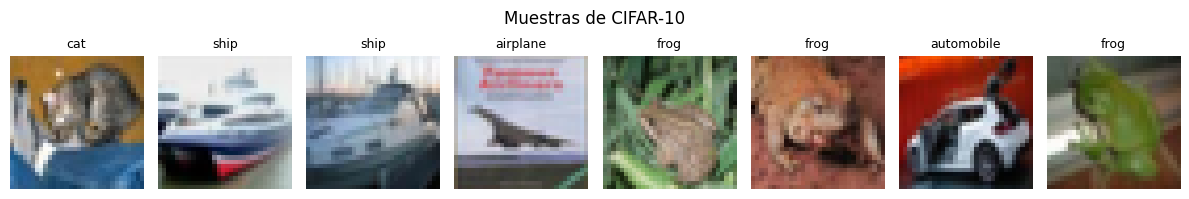

In [4]:
# Visualizar algunos ejemplos
def show_batch(images, labels, title="", n=8):
    fig, axes = plt.subplots(1, n, figsize=(n*1.5, 2))
    for i in range(n):
        img = images[i].cpu().permute(1, 2, 0).numpy()
        img = np.clip(img, 0, 1)
        axes[i].imshow(img)
        axes[i].set_title(CIFAR_CLASSES[labels[i]], fontsize=9)
        axes[i].axis('off')
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

x, y = next(iter(test_loader))
show_batch(x, y, "Muestras de CIFAR-10")


## 3. Modelo: ResNet-18

Usamos la arquitectura estándar de torchvision adaptada a CIFAR (32×32). Incluimos la **capa de normalización dentro del modelo** para poder aplicar el ataque sobre $[0,1]$.


In [5]:
class NormalizeLayer(nn.Module):
    """Capa que normaliza la entrada con mean/std fijos.

    Permite atacar en el espacio [0,1] mientras la red recibe entradas normalizadas.
    """
    def __init__(self, mean, std):
        super().__init__()
        self.register_buffer('mean', torch.tensor(mean).view(1, 3, 1, 1))
        self.register_buffer('std',  torch.tensor(std ).view(1, 3, 1, 1))

    def forward(self, x):
        return (x - self.mean) / self.std


def make_resnet18(num_classes=10):
    # ResNet-18 de torchvision adaptada a CIFAR (entrada 32x32)
    net = torchvision.models.resnet18(weights=None, num_classes=num_classes)
    # Para 32x32: kernel inicial 3x3, sin maxpool inicial
    net.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    net.maxpool = nn.Identity()
    return nn.Sequential(
        NormalizeLayer(CIFAR_MEAN, CIFAR_STD),
        net,
    )

model = make_resnet18().to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"Parámetros: {n_params:,}")


Parámetros: 11,173,962


## 4. Entrenamiento

~30 epochs alcanzan ~92% de accuracy limpia en CIFAR-10. Para Parte I esto es suficiente; en Parte II se puede entrenar más o cargar un modelo robusto de RobustBench.

**Tip:** si tienes prisa, baja `EPOCHS` a 10-15 y obtienes ~88% en pocos minutos en GPU T4.


In [6]:
EPOCHS = 30
LR = 0.1

optimizer = optim.SGD(model.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
criterion = nn.CrossEntropyLoss()

def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            preds = model(x).argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)
    return correct / total

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0., 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * y.size(0)
        correct += (out.argmax(dim=1) == y).sum().item()
        total += y.size(0)
    return total_loss / total, correct / total

# === DESCOMENTA PARA ENTRENAR ===
# history = []
# for epoch in range(1, EPOCHS+1):
#     tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
#     scheduler.step()
#     te_acc = evaluate(model, test_loader)
#     history.append((tr_loss, tr_acc, te_acc))
#     print(f"Epoch {epoch:2d} | loss {tr_loss:.3f} | train {tr_acc:.3f} | test {te_acc:.3f}")
#
# torch.save(model.state_dict(), 'resnet18_cifar10.pth')


In [7]:
# === ALTERNATIVA: cargar pesos pre-entrenados si ya entrenaste ===
# model.load_state_dict(torch.load('resnet18_cifar10.pth', map_location=device))

# Por ahora evaluamos con el modelo (vacío o cargado)
clean_acc = evaluate(model, test_loader)
print(f"Accuracy limpia: {clean_acc:.4f}")


Accuracy limpia: 0.1006


## 5. FGSM desde cero (didáctico)

**Recordatorio matemático.** El ataque resuelve:
$$\delta^{\text{FGSM}} = \arg\max_{\|\delta\|_\infty \leq \epsilon} \nabla_x \mathcal{L}(f_\theta(x), y)^\top \delta = \epsilon \cdot \operatorname{sign}(\nabla_x \mathcal{L})$$

Esto es la solución exacta del problema linealizado, vía dualidad Hölder ($\ell_\infty^* = \ell_1$): para maximizar un producto interno con norma $\ell_\infty$ acotada, se toma cada componente al extremo en la dirección del signo del gradiente.

**Implementación.** Solo necesitamos:
1. Activar `requires_grad` en la entrada $x$.
2. Forward + cálculo de pérdida con la etiqueta verdadera $y$.
3. Backward para obtener $\nabla_x \mathcal{L}$.
4. $x' = x + \epsilon \cdot \operatorname{sign}(\nabla_x \mathcal{L})$.
5. Clip a $[0,1]$ para mantener pixeles válidos.


In [8]:
def fgsm_attack(model, x, y, epsilon, criterion=nn.CrossEntropyLoss()):
    """FGSM: x_adv = clip( x + eps * sign(grad_x L(f(x), y)), 0, 1 )."""
    model.eval()
    x_adv = x.clone().detach().requires_grad_(True)

    logits = model(x_adv)
    loss = criterion(logits, y)

    grad = torch.autograd.grad(loss, x_adv, retain_graph=False, create_graph=False)[0]

    x_adv = x_adv.detach() + epsilon * grad.sign()
    x_adv = torch.clamp(x_adv, 0.0, 1.0)
    return x_adv


def evaluate_attack(model, loader, attack_fn, epsilon):
    """Evalúa accuracy bajo un ataque dado."""
    model.eval()
    correct, total = 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        x_adv = attack_fn(model, x, y, epsilon)
        with torch.no_grad():
            preds = model(x_adv).argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)
    return correct / total


## 6. Curva de robustez: accuracy vs $\epsilon$

El experimento clásico: variar la magnitud de la perturbación y medir cuánto cae la accuracy. Para CIFAR-10 el valor estándar de la literatura es $\epsilon = 8/255$.


In [9]:
epsilons = [0, 1/255, 2/255, 4/255, 8/255, 16/255]
accs = []
for eps in epsilons:
    if eps == 0:
        acc = evaluate(model, test_loader)
    else:
        acc = evaluate_attack(model, test_loader, fgsm_attack, eps)
    accs.append(acc)
    print(f"epsilon = {eps:.4f} ({eps*255:.1f}/255) -> accuracy = {acc:.4f}")


epsilon = 0.0000 (0.0/255) -> accuracy = 0.1006
epsilon = 0.0039 (1.0/255) -> accuracy = 0.0877
epsilon = 0.0078 (2.0/255) -> accuracy = 0.0538
epsilon = 0.0157 (4.0/255) -> accuracy = 0.0076
epsilon = 0.0314 (8.0/255) -> accuracy = 0.0001
epsilon = 0.0627 (16.0/255) -> accuracy = 0.0000


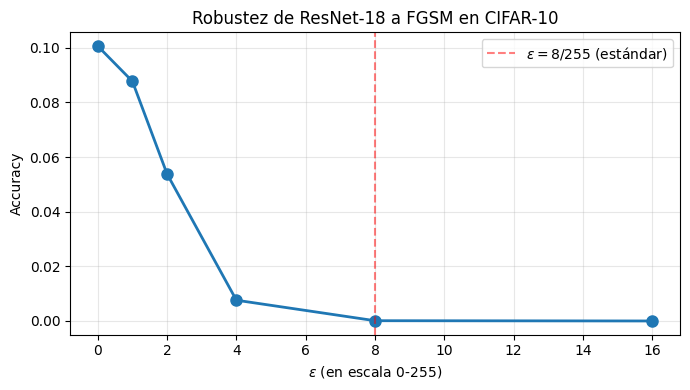

In [10]:
plt.figure(figsize=(7, 4))
plt.plot([e*255 for e in epsilons], accs, 'o-', linewidth=2, markersize=8)
plt.xlabel(r'$\epsilon$ (en escala 0-255)')
plt.ylabel('Accuracy')
plt.title('Robustez de ResNet-18 a FGSM en CIFAR-10')
plt.grid(True, alpha=0.3)
plt.axvline(x=8, color='red', linestyle='--', alpha=0.5, label=r'$\epsilon=8/255$ (estándar)')
plt.legend()
plt.tight_layout()
plt.show()


## 7. Visualización: original vs adversaria vs perturbación

<>:27: SyntaxWarning: invalid escape sequence '\e'
<>:27: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_1798/65248708.py:27: SyntaxWarning: invalid escape sequence '\e'
  plt.suptitle(f'FGSM con $\epsilon = {epsilon*255:.0f}/255$', fontsize=11)


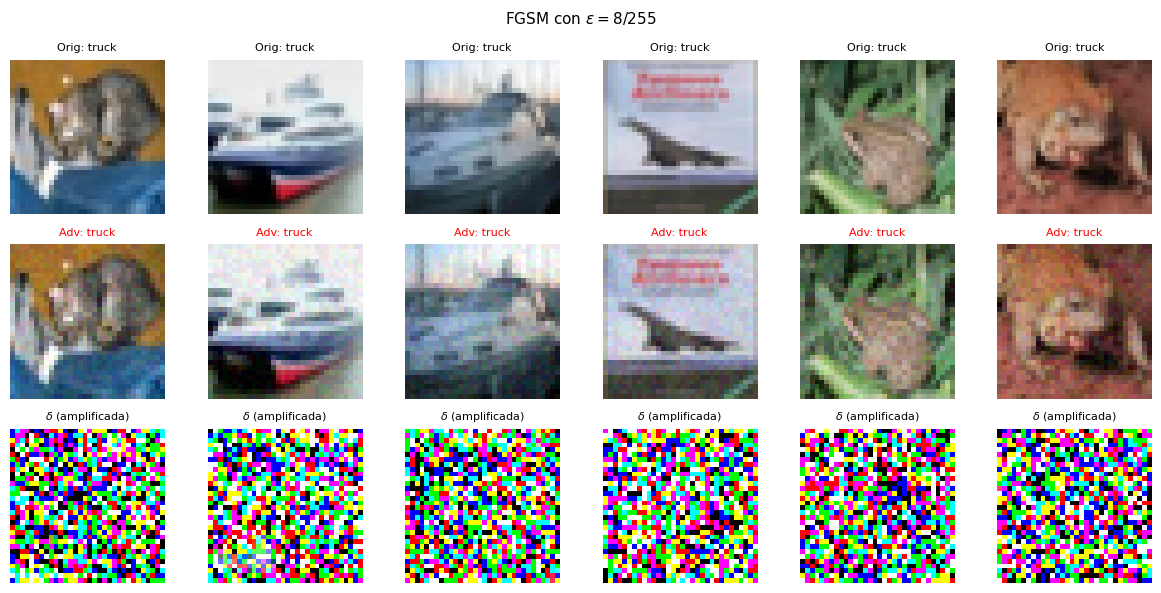

In [11]:
def visualize_adversarial(model, x, y, epsilon, n=6):
    model.eval()
    x_adv = fgsm_attack(model, x[:n].to(device), y[:n].to(device), epsilon)

    with torch.no_grad():
        clean_pred = model(x[:n].to(device)).argmax(dim=1).cpu()
        adv_pred   = model(x_adv).argmax(dim=1).cpu()

    perturbation = (x_adv.cpu() - x[:n]) / (2 * epsilon) + 0.5  # normalizar para ver

    fig, axes = plt.subplots(3, n, figsize=(2*n, 6))
    for i in range(n):
        axes[0, i].imshow(x[i].permute(1, 2, 0).numpy())
        axes[0, i].set_title(f'Orig: {CIFAR_CLASSES[clean_pred[i]]}', fontsize=8)
        axes[0, i].axis('off')

        axes[1, i].imshow(x_adv[i].cpu().permute(1, 2, 0).numpy())
        color = 'red' if adv_pred[i] != y[i] else 'green'
        axes[1, i].set_title(f'Adv: {CIFAR_CLASSES[adv_pred[i]]}',
                             fontsize=8, color=color)
        axes[1, i].axis('off')

        axes[2, i].imshow(perturbation[i].permute(1, 2, 0).numpy())
        axes[2, i].set_title(r'$\delta$ (amplificada)', fontsize=8)
        axes[2, i].axis('off')

    plt.suptitle(f'FGSM con $\epsilon = {epsilon*255:.0f}/255$', fontsize=11)
    plt.tight_layout()
    plt.show()

x_vis, y_vis = next(iter(test_loader))
visualize_adversarial(model, x_vis, y_vis, epsilon=8/255, n=6)


## 8. Comparación con `torchattacks`

Verificamos que nuestra implementación coincida con la librería estándar.


In [12]:
import torchattacks

atk = torchattacks.FGSM(model, eps=8/255)

correct_ours, correct_lib, total = 0, 0, 0
for x, y in test_loader:
    x, y = x.to(device), y.to(device)
    x_adv_ours = fgsm_attack(model, x, y, 8/255)
    x_adv_lib  = atk(x, y)
    with torch.no_grad():
        correct_ours += (model(x_adv_ours).argmax(1) == y).sum().item()
        correct_lib  += (model(x_adv_lib ).argmax(1) == y).sum().item()
    total += y.size(0)

print(f"Accuracy bajo FGSM (ours):         {correct_ours/total:.4f}")
print(f"Accuracy bajo FGSM (torchattacks): {correct_lib /total:.4f}")
print("Las dos implementaciones deben dar resultados muy similares.")


Accuracy bajo FGSM (ours):         0.0001
Accuracy bajo FGSM (torchattacks): 0.0001
Las dos implementaciones deben dar resultados muy similares.


## 9. Próximos pasos (Parte II — entrega 11 de junio)

- [ ] **PGD** ($\ell_\infty$, $\ell_2$): ascenso de gradiente proyectado iterativo. Ataque mucho más fuerte que FGSM.
- [ ] **Carlini & Wagner ($\ell_2$)**: ataque de optimización con búsqueda binaria sobre el coeficiente de Lagrange.
- [ ] Comparar contra **modelo robusto de RobustBench** (`robustbench.utils.load_model`) — ver cuánto cae la accuracy adversaria del modelo defendido.
- [ ] **Transferibilidad**: generar adversarios contra ResNet-18 y evaluarlos en otra arquitectura (VGG, ViT-small).
- [ ] Discutir el problema min-max de Madry et al.: $\min_\theta \mathbb{E}[\max_{\|\delta\| \leq \epsilon} \mathcal{L}(f_\theta(x+\delta), y)]$.
- [ ] (Opcional) **AutoAttack** como evaluación final de robustez.

## Referencias

1. Goodfellow, Shlens, Szegedy. *Explaining and Harnessing Adversarial Examples*. ICLR 2015.
2. Madry, Makelov, Schmidt, Tsipras, Vladu. *Towards Deep Learning Models Resistant to Adversarial Attacks*. ICLR 2018.
3. Carlini, Wagner. *Towards Evaluating the Robustness of Neural Networks*. IEEE S&P 2017.
4. Croce et al. *RobustBench: a standardized adversarial robustness benchmark*. NeurIPS Datasets 2021.
5. Kim. *Torchattacks: A PyTorch Repository for Adversarial Attacks*. arXiv:2010.01950.
